# Imports

In [1]:
from model_builder import ModelBuilder
from model_utils import *
import random
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import colorsys
from sklearn.decomposition import PCA
plt.rcParams["font.family"] = "Times New Roman"
import warnings
warnings.filterwarnings("ignore")

In [2]:
with open("config.json", "rb") as json_file:
    config = json.load(json_file)
config

{'becker': {'filename': 'beckerestimation_output_conversation_level.csv',
  'cols_to_ignore': ['conversation_num',
   'mean_pre_discussion_error',
   'mean_post_discussion_error',
   'median_pre_discussion_error',
   'median_post_discussion_error',
   'median_pre_discussion_error_pct',
   'median_post_discussion_error_pct',
   'mean_pre_discussion_error_pct',
   'mean_post_discussion_error_pct',
   'reverse_mean_post_discussion_error_pct',
   'reverse_median_post_discussion_error_pct',
   'question',
   'chatrooms',
   'trial_indx']},
 'csop': {'filename': 'csop_output_conversation_level.csv',
  'cols_to_ignore': ['conversation_num',
   'batch_num',
   'round_num',
   'round_index',
   'task_index',
   'complexity',
   'type',
   'social_perceptiveness',
   'skill',
   'normalized_score',
   'score',
   'duration',
   'efficiency']},
 'csopII': {'filename': 'csopII_output_conversation_level.csv',
  'cols_to_ignore': ['conversation_num',
   'batch_num',
   'vis_img',
   'int_verb',
   '

# Jury

In [3]:
# Define the basic model
juries_model = ModelBuilder(dataset_names = ["juries"])
juries_model.select_target(target=["majority_pct"])
juries_model.define_model(model_type = 'rf')

# CSOP (blended)

In [4]:
csop_blended_model = ModelBuilder(dataset_names = ["csop", "csopII"])
csop_blended_model.select_target(target=["efficiency", "efficiency"])
csop_blended_model.define_model(model_type = 'rf')

# DAT

In [5]:
dat_model = ModelBuilder(dataset_names = ["dat"])
dat_model.select_target(target=["efficiency"])
dat_model.define_model(model_type = 'rf')

# Estimation

In [6]:
estimation_blended_model = ModelBuilder(dataset_names = ["gurcay", "becker"])
estimation_blended_model.select_target(target=["mean_post_discussion_error_pct", "mean_post_discussion_error_pct"])
estimation_blended_model.define_model(model_type = 'rf')

# Create a PCA plot of the conversation features, colored by task

In [7]:
juries_data = pd.read_csv('../output/jury_output_conversation_level.csv')
csop_data = pd.read_csv('../output/csop_output_conversation_level.csv')
csopII_data = pd.read_csv('../output/csopII_output_conversation_level.csv')
dat_data = pd.read_csv('../output/dat_output_conversation_level.csv')
becker_data = pd.read_csv('../output/beckerestimation_output_conversation_level.csv')
gurcay_data = pd.read_csv('../output/gurcay2015estimation_output_conversation_level.csv')

In [8]:
juries_data, csop_data, csopII_data, dat_data, becker_data, gurcay_data = drop_non_common_columns([juries_data, csop_data, csopII_data, dat_data, becker_data, gurcay_data])

csop_blended_data = pd.concat([csop_data,csopII_data], axis=0)
estimation_blended_data = pd.concat([becker_data,gurcay_data], axis=0)

In [9]:
juries_data, csop_blended_data, dat_data, estimation_blended_data = get_numeric_cols([juries_data, csop_blended_data, dat_data, estimation_blended_data])

In [10]:
juries_data, csop_blended_data, csop_data, csopII_data, dat_data, estimation_blended_data, becker_data, gurcay_data = get_convs_with_min_value([juries_data, csop_blended_data, csop_data, csopII_data, dat_data, estimation_blended_data, becker_data, gurcay_data], "sum_num_messages", 10)

# PCA of Datasets

How do people "speak differently" across different tasks? Can we identify these different patterns of speaking just through clustering each conversation?

In [11]:
labels = ["Mock Jury", "Room Assignment Task", "Divergent Association Task", "Estimation"]
dataset_labels = ["Mock Jury", "CSOP", "CSOPII", "DAT", "Estimation (Becker)", "Estimation (Gurcay)"]

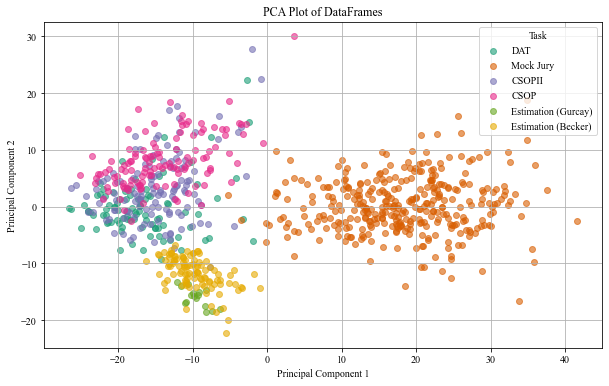

In [12]:
pca_results = plot_pca_of_dataframes(juries_data, csop_data, csopII_data, dat_data, becker_data, gurcay_data, labels=dataset_labels)

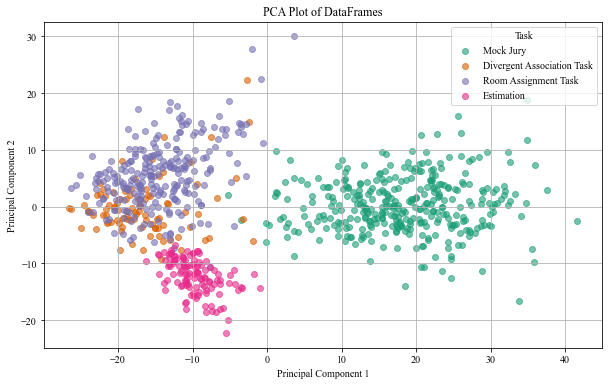

In [13]:
pca_results = plot_pca_of_dataframes(juries_data, csop_blended_data, dat_data, estimation_blended_data, labels=labels)

In [14]:
pca_results.explained_variance_ratio_

array([0.28305965, 0.05467009])

In [15]:
examine_top_n_components(pca_results, n=10)

Top 5 Features for PC1:
                                     Feature       PC1       PC2   PC1_abs  \
481               average_user_avg_num_chars  0.055279 -0.003081  0.055279   
722  average_user_avg_nltk_english_stopwords  0.055277  0.000367  0.055277   
678               average_user_avg_num_words  0.055266 -0.001289  0.055266   
216           average_nltk_english_stopwords  0.055121  0.001122  0.055121   
302                        average_num_chars  0.055113 -0.002596  0.055113   
557                        average_num_words  0.055079 -0.000560  0.055079   
2                 average_user_sum_num_chars  0.054876  0.034931  0.054876   
403  average_user_sum_nltk_english_stopwords  0.054757  0.034861  0.054757   
245          average_user_avg_cognitive_mech  0.054608 -0.001255  0.054608   
832                   average_user_avg_verbs  0.054550  0.000480  0.054550   

      PC2_abs  
481  0.003081  
722  0.000367  
678  0.001289  
216  0.001122  
302  0.002596  
557  0.000560  
2    

,Feature,PC1,PC2,PC1_abs,PC2_abs
0,min_user_sum_indirect_(greeting),-0.002141,0.009778,0.002141,0.009778
1,average_user_sum_negative_affect,0.036884,0.016063,0.036884,0.016063
2,average_user_sum_num_chars,0.054876,0.034931,0.054876,0.034931
3,average_1st_person,0.036913,-0.007722,0.036913,0.007722
4,min_user_sum_swear,0.020788,0.016728,0.020788,0.016728
...,...,...,...,...,...
1034,stdev_dale_chall_score,0.033078,-0.025646,0.033078,0.025646
1035,stdev_user_avg_inclusive,0.020521,-0.016577,0.020521,0.016577
1036,stdev_user_avg_article,0.039100,-0.036543,0.039100,0.036543
1037,average_user_avg_exclusive,0.051713,-0.000846,0.051713,0.000846


PC 1 mostly captures *the quantity of how much people talk*.

PC 2 captures a combination of ideas: Type-Token Ratio, Number of Messages, Subjectivity, Positivity.

In general, Juries talk the most > Estimation second > CSOP / DAT last.

In general, Estimation has a lower PC2 (lower type/token ratio, lower positivity...)

## How much do all the other PC's tell us?
Answer: not a ton...

In [23]:
full_pca = get_pca_of_dataframes([juries_data, csop_blended_data, dat_data, estimation_blended_data], n_components = 10)

([<matplotlib.axis.XTick at 0x142ea7610>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9')])

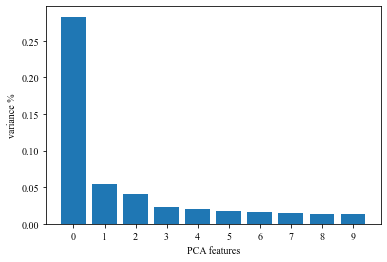

In [19]:
var = full_pca.explained_variance_ratio_
plt.bar(list(range(var.shape[0])),var)
feature = range(full_pca.n_components_)
plt.xlabel('PCA features')
plt.ylabel('variance %')
plt.xticks(feature)

# PCA of Features

Can we now model each feature as a point, and see how the different features relate to each other?

(The following code generates an interactive PCA plot, but opens in a brower window.)

Columns with NaN values: ['min_money', 'min_quantifier', 'min_deference', 'min_exclusive', 'max_user_avg_indirect_(btw)', 'min_sadness', 'min_user_avg_religion', 'min_first_person_singular', 'min_bio', 'min_2nd_person', 'min_feel', 'min_num_messages', 'min_direct_question', 'min_user_sum_direct_question', 'average_user_avg_num_messages', 'max_haspositive', 'average_user_sum_indirect_(btw)', 'min_user_avg_direct_question', 'min_please_start', 'average_indirect_(btw)', 'stdev_user_avg_indirect_(btw)', 'stdev_indirect_(btw)', 'min_discrepancies', 'min_user_sum_religion', 'min_2nd_person_start', 'min_user_sum_NTRI', 'min_home', 'min_inclusive', 'min_user_avg_sexual', 'max_user_avg_num_messages', 'min_adverbs', 'min_user_avg_body', 'min_body', 'min_user_sum_apologizing', 'min_achievement', 'stdev_user_sum_indirect_(btw)', 'min_insight', 'min_1st_person_start', 'min_relative', 'min_1st_person_pl.', 'min_tentativeness', 'min_past_tense', 'min_hashedge', 'stdev_user_avg_num_messages', 'min_neg

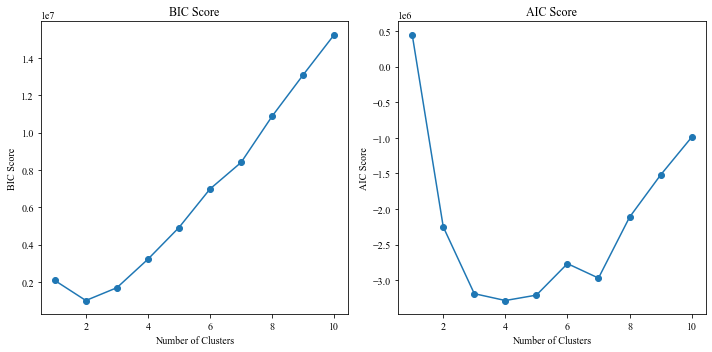

In [17]:
visualize_feature_clusters([juries_data, csop_blended_data, dat_data, estimation_blended_data], use_aic = True)

## PCA of User Features